# LLOYD BAD
# ODT BAD

In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [2]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise3D') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study5') # path dir to save outputs in

study_prefix = 'study5' # start of dir name of output_root in set_parameters
studies = ['a', 'b'] # individual study identifier (end of dir name of output_root in set_parameters)

In [3]:
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes.csv', index=False)
get_params3d(root_dir, study_prefix, studies).fillna(0).to_csv(out_dir / 'params.csv', index=False)

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study5a-0a', 'study5b-0b'])

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [4]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [5]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99.9%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    #f'{qual_part}_min_angle_{qual_metric}',
    #f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        #f'{qual_part}_min_angle_{qual_metric}',
        #f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        #f'{qual_part}_aspect_ratio_{qual_metric}',
        #f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

308


Highest element count:
	14613R - 517194


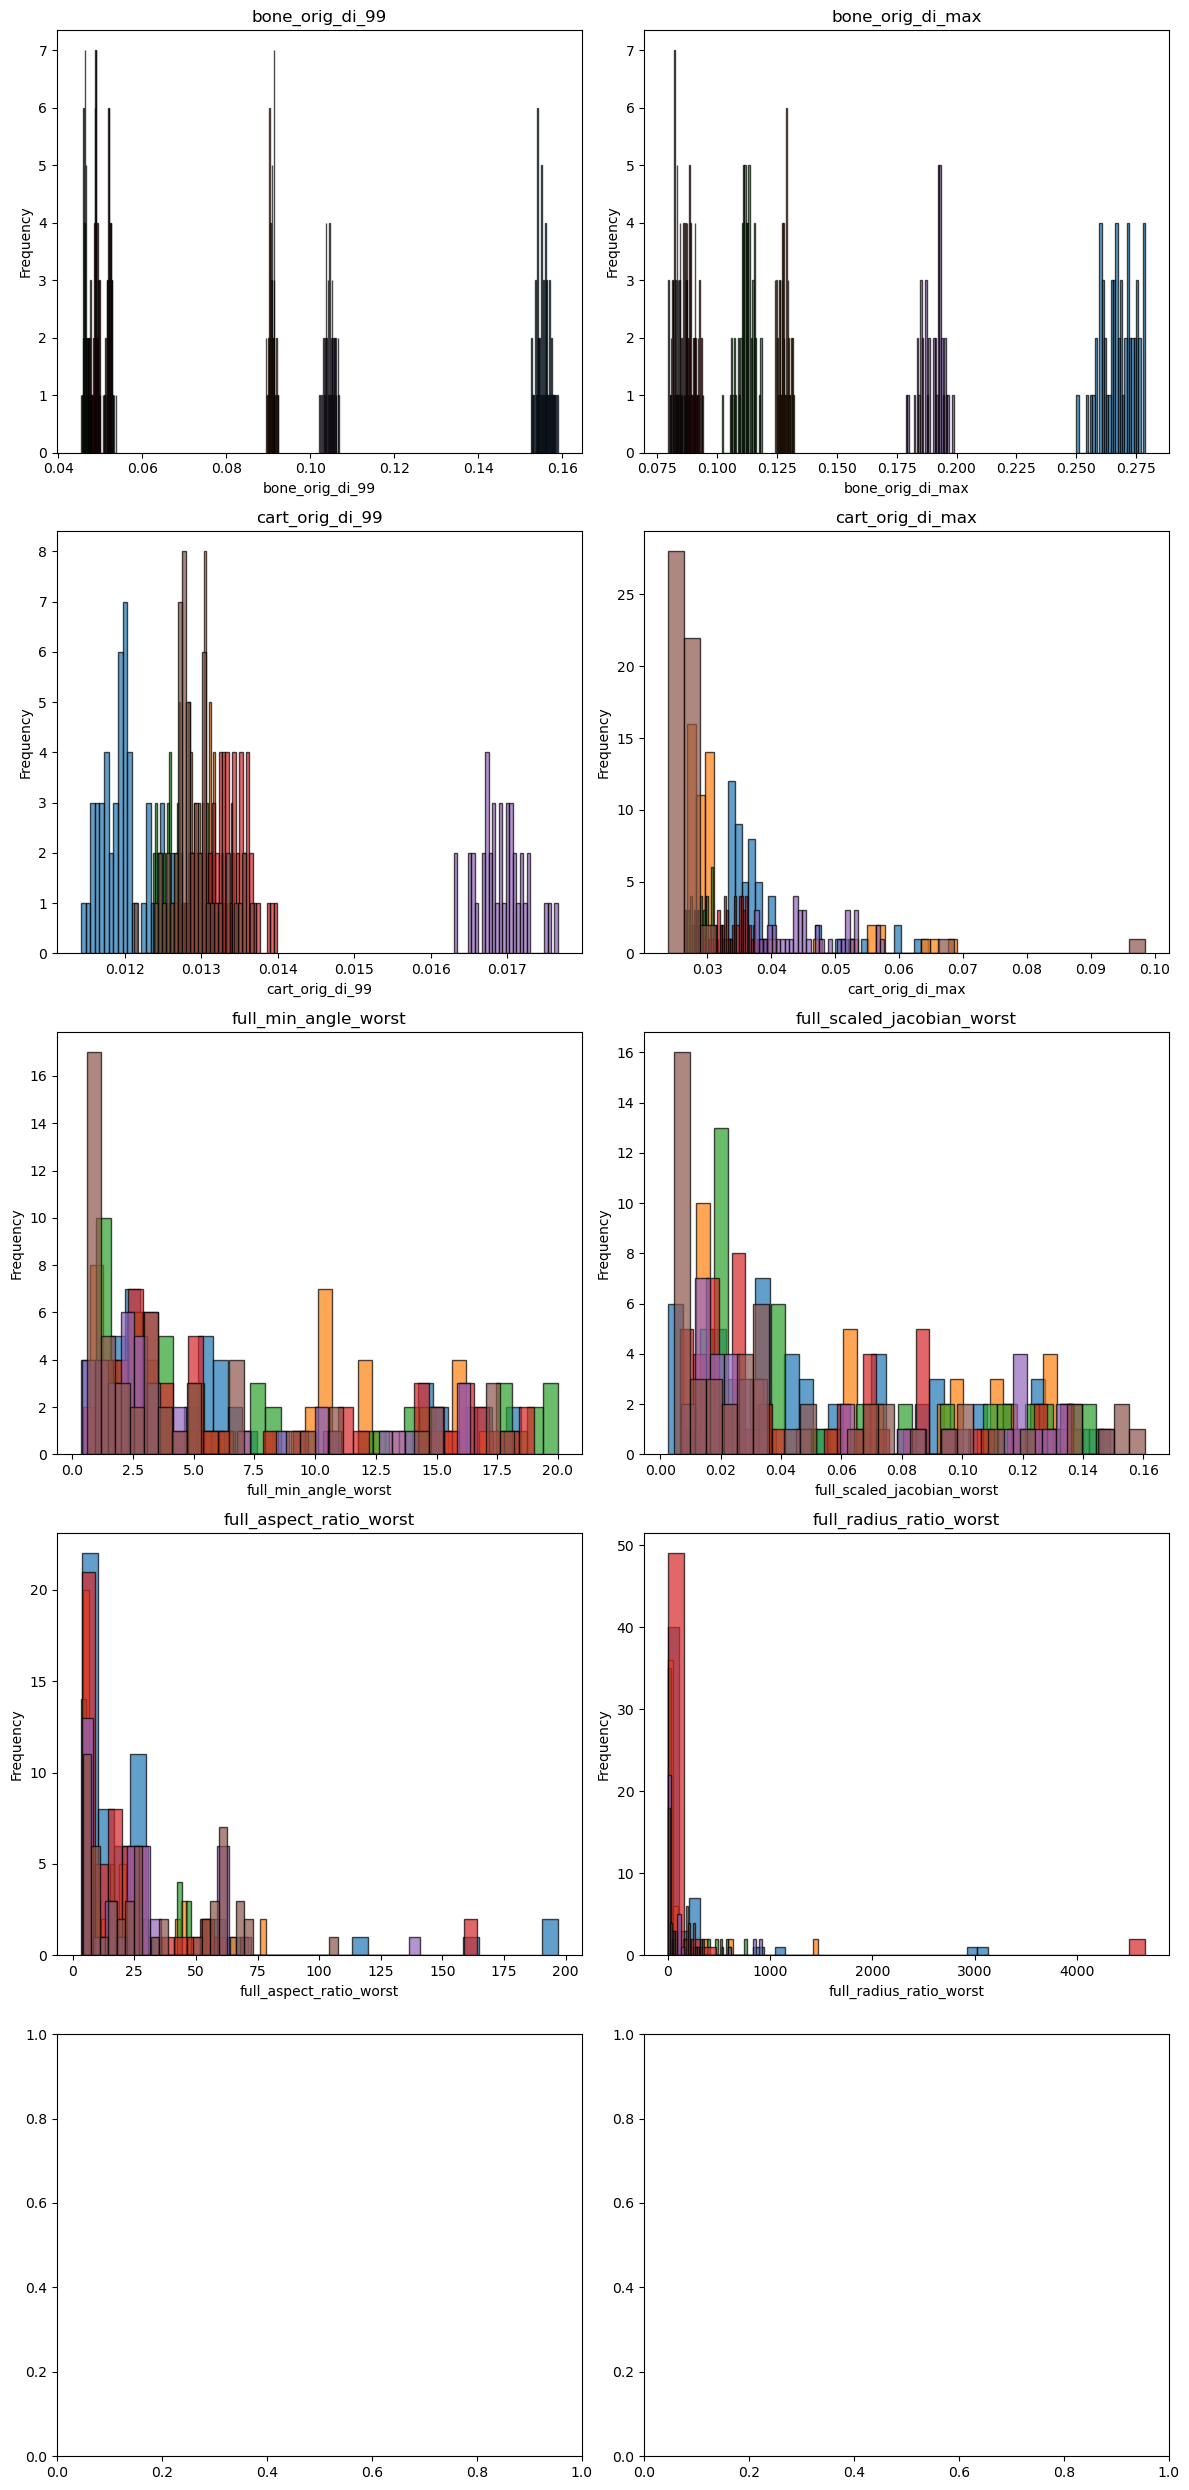

In [6]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [7]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

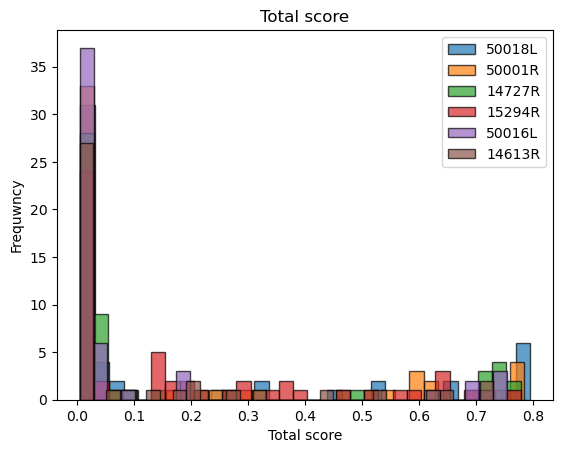

In [8]:
# Get scores

decay = 2
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [9]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.taper_size,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.lloyd.freeze_bound,p_h,cgal_params.odt.freeze_bound,mean_rank,median_rank,best_rank,n_runs
28,0.3,False,False,0.0000,5.0,0.0000,8.333333,5.00,1.0,6
29,0.3,False,False,0.0000,8.5,0.0000,9.333333,2.00,1.0,6
1,0.2,False,False,0.0000,5.0,0.0000,11.666667,9.00,3.0,6
2,0.2,False,False,0.0000,8.5,0.0000,13.500000,12.00,4.0,6
47,0.3,True,True,0.0005,8.5,0.0010,14.166667,13.50,1.0,6
0,0.2,False,False,0.0000,3.0,0.0000,14.666667,15.00,1.0,6
33,0.3,False,True,0.0010,3.0,0.0000,15.333333,14.50,10.0,6
52,0.3,True,True,0.0010,8.5,0.0005,15.400000,13.00,7.0,5
27,0.3,False,False,0.0000,3.0,0.0000,16.166667,15.00,3.0,6
35,0.3,False,True,0.0010,8.5,0.0000,16.666667,10.00,3.0,6


In [13]:
sub = '50016L'
df_score_param[df_score_param['sub']==sub][[x for x in df_score_param.columns if 'worst' not in x]].head(10)

,sub,bone,run_id,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.lloyd.freeze_bound,p_h,cgal_params.odt.freeze_bound
14,50016L,tpm,0-0-2-0b,0.753185,1.0,0.2,False,False,0.0000,3.0,0.0
18,50016L,tpm,0-2-10-0b,0.746115,2.0,0.3,False,True,0.0005,8.5,0.0
21,50016L,tpm,0-1-9-0b,0.732614,3.0,0.3,False,True,0.0010,5.0,0.0
24,50016L,tpm,0-1-2-0b,0.720201,4.0,0.2,False,False,0.0000,5.0,0.0
30,50016L,tpm,0-1-11-0b,0.697520,5.0,0.3,False,False,0.0000,5.0,0.0
33,50016L,tpm,0-0-11-0b,0.684430,6.0,0.3,False,False,0.0000,3.0,0.0
40,50016L,tpm,0-2-2-0b,0.629709,7.0,0.2,False,False,0.0000,8.5,0.0
82,50016L,tpm,0-1-10-0b,0.197824,8.0,0.3,False,True,0.0005,5.0,0.0
83,50016L,tpm,0-2-9-0b,0.194747,9.0,0.3,False,True,0.0010,8.5,0.0
86,50016L,tpm,0-2-11-0b,0.184954,10.0,0.3,False,False,0.0000,8.5,0.0


In [14]:
df_score_qual[df_score_qual['sub']==sub][['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if 'worst_y' in x]].head(10)

,sub,bone,run_id,full_min_angle_worst_y,full_radius_ratio_worst_y,full_aspect_ratio_worst_y,full_scaled_jacobian_worst_y
14,50016L,tpm,0-0-2-0b,17.350871,4.004620,4.348678,0.151460
18,50016L,tpm,0-2-10-0b,18.189219,4.018726,4.295223,0.136862
21,50016L,tpm,0-1-9-0b,17.027317,3.841534,4.306442,0.110617
24,50016L,tpm,0-1-2-0b,17.209254,4.581242,4.038605,0.151812
30,50016L,tpm,0-1-11-0b,14.247792,4.034119,4.577955,0.146452
33,50016L,tpm,0-0-11-0b,15.104146,4.806560,4.172648,0.160589
40,50016L,tpm,0-2-2-0b,14.699938,4.614556,4.492403,0.120676
82,50016L,tpm,0-1-10-0b,11.005919,8.791440,5.669923,0.093574
83,50016L,tpm,0-2-9-0b,10.973639,8.621849,5.675096,0.086516
86,50016L,tpm,0-2-11-0b,9.894888,5.981052,6.163141,0.136811


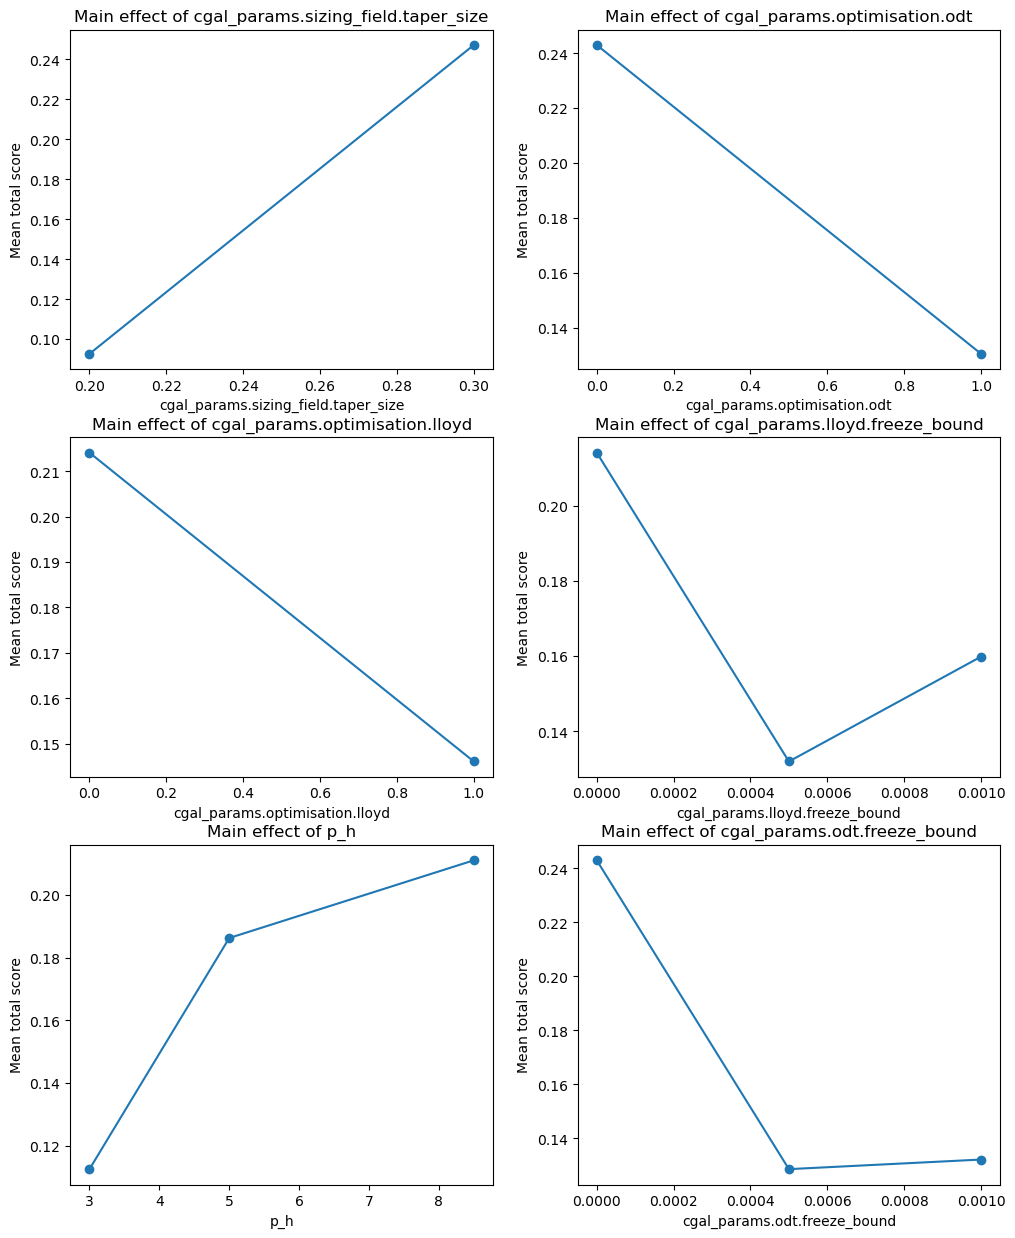

In [17]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for i, p in enumerate(df_param.columns[3:]):
    eff = (
        df_score_param
        .groupby(p)['total']
        .mean()
        .reset_index()
        .sort_values(p)
    )

    ax[i].plot(eff[p], eff['total'], marker='o')
    ax[i].set_title(f'Main effect of {p}')
    ax[i].set_xlabel(p)
    ax[i].set_ylabel('Mean total score')
